# Hot-Carrier Relaxation — `relaxation.py`

This notebook demonstrates the two relaxation channels in `plytrons.relaxation`,
following Saavedra, Asenjo-Garcia & Garcia de Abajo, *ACS Photonics* **3**, 1637 (2016).

| Part | Physics | Key function |
|---|---|---|
| B | Electron–electron scattering | `ee_scattering_rates`, `ee_lifetimes` |
| C | Electron–phonon scattering | `electronic_specific_heat`, `eph_rate`, `eph_rate_vs_temperature` |
| D | Combined effective lifetime | `effective_lifetime` |
| D+ | State-resolved hot-carrier distribution | `hot_e_dist_resolved` |

**Architecture**

```
hot_carriers.py   ← PRIMARY CORE   : optical excitation (Fermi golden rule)
relaxation.py     ← SECONDARY CORE : e-e + e-ph (Saavedra et al. 2016)
                               ↓
          hot_e_dist_resolved  : combines both with state-resolved broadening
```

## Step 0 — Imports

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plytrons.quantum_well as qw
from plytrons.relaxation import (
    # Part B
    ee_scattering_rates,
    ee_lifetimes,
    # Part C
    electronic_specific_heat,
    eph_rate,
    eph_lifetime,
    eph_rate_vs_temperature,
    EPH_COUPLING,
    # Part D
    effective_lifetime,
    hot_e_dist_resolved,
)

from numba.core.errors import NumbaTypeSafetyWarning
warnings.simplefilter('ignore', category=NumbaTypeSafetyWarning)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})

---
## Step 1 — System parameters

We use a silver nanosphere, D = 5 nm.  
The quantum-well bound states are the same as in `quantum_well_example.ipynb`.

In [2]:
D    = 5.0    # sphere diameter [nm]
a    = D / 2  # sphere radius   [nm]
EF   = 5.5    # Fermi energy of silver [eV]
T_K  = 300.0  # electron temperature [K]

# Silver Drude parameters
wp_eV    = 9.07
eps_b    = 4.18
gamma_eV = 0.060

# Quantum-well states
E_matrix = qw.get_bound_states(a)
A_matrix = qw.get_normalization(a, E_matrix)
e_states = qw.e_state_assembly(E_matrix, A_matrix)

lmax_qw = len(e_states)
N_tot   = sum(e_states[l].Eb.size for l in range(lmax_qw))
print(f'D = {D} nm,  a = {a} nm,  T = {T_K} K')
print(f'QW states: lmax = {lmax_qw-1},  N = {N_tot}')
print(f'EF = {EF} eV')

D = 5.0 nm,  a = 2.5 nm,  T = 300.0 K
QW states: lmax = 42,  N = 296
EF = 5.5 eV


---
## Step 2 (Part B) — Electron–electron scattering rate matrix

$\gamma_{j\leftarrow i}^{\rm e-e}$ is the rate for an electron to scatter from
state $i$ into state $j$ via the screened Coulomb interaction:

$$\gamma_{j\leftarrow i} = \frac{8\pi k_C}{\hbar a} |\tilde{A}_i|^2 |\tilde{A}_j|^2
\sum_{\ell_c} \text{angular}(\ell_j,\ell_c,\ell_i)\,
(-\mathrm{Im}\,G_{\ell_c}(\omega_{ij}))\,[n_T(|\omega_{ij}|)+\Theta(\omega_{ij})]$$

The rate matrix has shape $(N, N)$ where $N$ is the total number of bound states.

In [3]:
print('Computing e-e scattering rate matrix...')
gamma_matrix, E_all, l_all = ee_scattering_rates(
    a_nm     = a,
    e_state  = e_states,
    T_K      = T_K,
    wp_eV    = wp_eV,
    eps_b    = eps_b,
    gamma_eV = gamma_eV,
    Nr       = 128,
    lc_max   = 0,       # 0 = auto (uses lmax_qw - 1)
)
print(f'Done.  gamma_matrix shape: {gamma_matrix.shape}')
print(f'Max rate: {gamma_matrix.max():.4g} fs^-1')
print(f'Mean non-zero rate: {gamma_matrix[gamma_matrix>0].mean():.4g} fs^-1')

Computing e-e scattering rate matrix...


c:\users\pablo\proyectos\plytrons\plytrons\relaxation.py:415: NumbaWarning: Cannot cache compiled function "_Gl_screened" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  gamma_matrix[j, i] = _gamma_ee_pair(
c:\users\pablo\proyectos\plytrons\plytrons\relaxation.py:415: NumbaWarning: Cannot cache compiled function "_gamma_ee_pair" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  gamma_matrix[j, i] = _gamma_ee_pair(


Done.  gamma_matrix shape: (296, 296)
Max rate: 3.184e+04 fs^-1
Mean non-zero rate: 32.07 fs^-1


---
### Rate matrix visualisation

Each pixel $(j, i)$ shows the scattering rate $\gamma_{j\leftarrow i}$ on a log scale.
Only allowed transitions (triangle rule + parity) are non-zero.

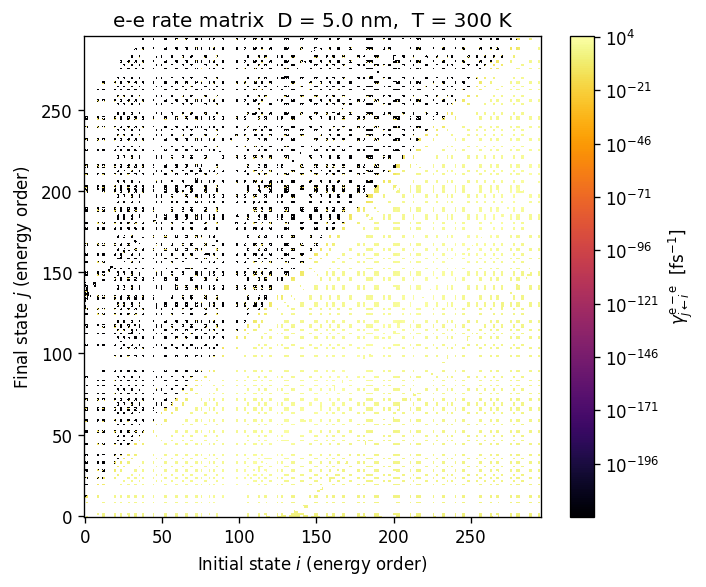

In [4]:
# Sort states by energy for a readable display
sort_idx = np.argsort(E_all)
G_sorted = gamma_matrix[np.ix_(sort_idx, sort_idx)]
E_sorted = E_all[sort_idx]

# Mask diagonal and zeros
G_plot = np.where(G_sorted > 0, G_sorted, np.nan)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(G_plot, origin='lower', aspect='auto',
               norm=mcolors.LogNorm(vmin=G_sorted[G_sorted>0].min(),
                                    vmax=G_sorted.max()),
               cmap='inferno')
plt.colorbar(im, ax=ax, label=r'$\gamma_{j\leftarrow i}^{\rm e-e}$  [fs$^{-1}$]')
ax.set_xlabel('Initial state $i$ (energy order)')
ax.set_ylabel('Final state $j$ (energy order)')
ax.set_title(f'e-e rate matrix  D = {D} nm,  T = {T_K:.0f} K')
plt.tight_layout()
plt.show()

---
## Step 3 (Part B) — Electron–electron lifetimes

For **electrons** ($E_i > E_F$, eqs 9):
$$\frac{1}{\tau_i^{\rm e-e}} = \sum_j (1-f_j)\,\gamma_{j\leftarrow i}$$

For **holes** ($E_i < E_F$, eq 10):
$$\frac{1}{\tau_i^{\rm e-e}} = \sum_j f_j\,\gamma_{i\leftarrow j}$$

States deep below/above $E_F$ are Pauli-blocked and get very long lifetimes.

In [5]:
tau_ee, E_all2, l_all2 = ee_lifetimes(
    a_nm     = a,
    E_F      = EF,
    e_state  = e_states,
    T_K      = T_K,
    wp_eV    = wp_eV,
    eps_b    = eps_b,
    gamma_eV = gamma_eV,
)

# Sort by energy
sort_idx = np.argsort(E_all2)
E_s   = E_all2[sort_idx]
l_s   = l_all2[sort_idx]
tau_s = tau_ee[sort_idx]

# Separate electrons and holes
mask_e = E_s >= EF
mask_h = E_s <  EF

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.semilogy(E_s[mask_e], tau_s[mask_e], 'o', color='C0', ms=5, label='Electrons ($E > E_F$)')
ax.semilogy(E_s[mask_h], tau_s[mask_h], 's', color='C3', ms=5, label='Holes ($E < E_F$)')
ax.axvline(EF, ls='--', lw=1.2, color='k', label=f'$E_F$ = {EF} eV')
ax.set_xlabel('State energy (eV)')
ax.set_ylabel(r'$\tau^{\rm e-e}$  [fs]')
ax.set_title(f'e-e lifetimes  D = {D} nm,  T = {T_K:.0f} K')
ax.legend(fontsize=9)
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

# Print summary
hot_e = tau_s[mask_e]
if hot_e.size:
    print(f'Hot electrons:  tau_ee = {hot_e.min():.1f} ... {hot_e.max():.1f} fs  '
          f'(median {np.median(hot_e):.1f} fs)')
hot_h = tau_s[mask_h]
if hot_h.size:
    print(f'Hot holes:      tau_ee = {hot_h.min():.1f} ... {hot_h.max():.1f} fs  '
          f'(median {np.median(hot_h):.1f} fs)')

KeyboardInterrupt: 

---
## Step 4 (Part C) — Electronic specific heat and e-ph lifetime

The electron–phonon rate is $\gamma^{\rm e-ph} = G / c_e(T_e)$ where
$G$ is the electron–lattice coupling constant and $c_e$ is computed
from the QW states (recovers the Sommerfeld $c_e \propto T$ for large NPs).

| Material | $G$ [W m$^{-3}$ K$^{-1}$] |
|---|---|
| Silver | $3.5 \times 10^{16}$ |
| Gold | $3.0 \times 10^{16}$ |
| Copper | $1.0 \times 10^{17}$ |

In [ ]:
print('EPH_COUPLING dict (project units: eV/(fs nm^3 K)):')
for mat, G_val in EPH_COUPLING.items():
    print(f'  {mat:8s}: {G_val:.4g}')
print()

c_e = electronic_specific_heat(a, EF, e_states, T_K=T_K)
print(f'c_e at T = {T_K} K : {c_e:.4g} eV/(nm^3 K)')

gamma_eph = eph_rate(a, EF, e_states, T_K=T_K)
tau_eph   = eph_lifetime(a, EF, e_states, T_K=T_K)
print(f'gamma_eph = {gamma_eph:.4g} fs^-1   =>   tau_eph = {tau_eph:.1f} fs')

---
### $c_e(T)$ and $\tau^{\rm e-ph}(T)$ vs temperature

`eph_rate_vs_temperature` sweeps $c_e$ and $\gamma^{\rm e-ph}$ over a temperature grid.
The Sommerfeld linear approximation $c_e^{\rm Som} = \gamma_S T$ is shown for comparison
($\gamma_S = \pi^2 k_B^2 g(E_F) / 3$, bulk value for silver $\approx 65\,\mu$J m$^{-3}$ K$^{-2}$).

In [ ]:
T_array = np.linspace(100, 5000, 200)   # [K]

gamma_eph_arr, ce_arr = eph_rate_vs_temperature(
    a, EF, e_states, T_array
)
tau_eph_arr = np.where(gamma_eph_arr > 0, 1.0 / gamma_eph_arr, np.inf)

# Sommerfeld reference: gamma_S for bulk silver
k_B    = 8.617333262e-5   # eV/K
# Bulk DOS at EF for silver: g(EF) ~ 0.0093 eV^-1 nm^-3 (approximate)
g_EF   = 0.0093
gamma_S = (np.pi**2 * k_B**2 / 3) * g_EF   # eV / (nm^3 K^2)
ce_som  = gamma_S * T_array

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))

ax0.plot(T_array, ce_arr * 1e3, 'C0', lw=2, label='QW (this NP)')
ax0.plot(T_array, ce_som * 1e3, 'k--', lw=1.5, label='Sommerfeld (bulk)')
ax0.set_xlabel('Temperature (K)')
ax0.set_ylabel(r'$c_e$  [$10^{-3}$ eV nm$^{-3}$ K$^{-1}$]')
ax0.set_title('Electronic specific heat')
ax0.legend()
ax0.grid(True, ls=':')

ax1.plot(T_array, tau_eph_arr, 'C2', lw=2)
ax1.set_xlabel('Temperature (K)')
ax1.set_ylabel(r'$\tau^{\rm e-ph}$  [fs]')
ax1.set_title('Electron–phonon lifetime')
ax1.grid(True, ls=':')

fig.suptitle(f'D = {D} nm Ag sphere  (Silver, $G = 3.5\\times10^{{16}}$ W m$^{{-3}}$ K$^{{-1}}$)',
             y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 5 (Part D) — Combined effective lifetime

Matthiessen's rule:

$$\frac{1}{\tau_i^{\rm eff}} = \frac{1}{\tau_i^{\rm e-e}} + \frac{1}{\tau^{\rm e-ph}}$$

$\tau^{\rm e-ph}$ is state-independent (same for all states at a given $T$).  
$\tau^{\rm e-e}_i$ is state-dependent and typically **shorter** for states near $E_F$
(Fermi-liquid $\tau \propto (E-E_F)^{-2}$ behaviour).

In [ ]:
print('Computing effective lifetimes (e-e + e-ph)...')
tau_eff, E_eff, l_eff, tau_eph_scalar = effective_lifetime(
    a_nm     = a,
    E_F      = EF,
    e_state  = e_states,
    T_K      = T_K,
    wp_eV    = wp_eV,
    eps_b    = eps_b,
    gamma_eV = gamma_eV,
)
print(f'Done.  tau_eph (scalar) = {tau_eph_scalar:.1f} fs')

# Recompute tau_ee in energy-sorted order for comparison
sort_idx   = np.argsort(E_all2)
tau_ee_s   = tau_ee[sort_idx]

mask_e = E_eff >= EF
mask_h = E_eff <  EF

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(E_eff[mask_e], tau_ee_s[mask_e],  'o', color='C0', ms=5, alpha=0.7,
            label=r'$\tau^{\rm e-e}$ (electrons)')
ax.semilogy(E_eff[mask_e], tau_eff[mask_e],   '^', color='C1', ms=5,
            label=r'$\tau^{\rm eff}$ (electrons)')
ax.semilogy(E_eff[mask_h], tau_ee_s[mask_h],  's', color='C3', ms=5, alpha=0.7,
            label=r'$\tau^{\rm e-e}$ (holes)')
ax.semilogy(E_eff[mask_h], tau_eff[mask_h],   'v', color='C4', ms=5,
            label=r'$\tau^{\rm eff}$ (holes)')
ax.axhline(tau_eph_scalar, ls='--', lw=1.2, color='k',
           label=fr'$\tau^{{\rm e-ph}}$ = {tau_eph_scalar:.0f} fs')
ax.axvline(EF, ls=':', lw=1, color='gray')
ax.set_xlabel('State energy (eV)')
ax.set_ylabel(r'Lifetime [fs]')
ax.set_title(f'Effective vs e-e lifetimes  D = {D} nm,  T = {T_K:.0f} K')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

---
## Step 6 (Part D+) — State-resolved hot-carrier distribution

`hot_e_dist_resolved` is the drop-in replacement for `hot_e_dist` when you
want **state-dependent Lorentzian broadening** instead of a single phenomenological $\tau$.

Each state $i$ contributes a Lorentzian of width $\gamma_i = \hbar / \tau_i^{\rm eff}$:

$$n_e(E_f) = S \sum_i \frac{4\gamma_i}{\hbar} f_i (1-f_f) \frac{|M_{fi}|^2}
{(h\nu - E_f + E_i)^2 + \gamma_i^2}$$

You need to run a BCM solve first to get `X_lm` and `Pabs_peak`.  
Below we build a minimal single-sphere BCM solve to obtain them.

In [ ]:
from scipy.constants import hbar as hbar_si, eV as eV_si, speed_of_light
from scipy.constants import physical_constants
import plytrons.bcm_sphere as bcm
from plytrons.bcm_sphere import EField, BCMObject
from plytrons.math_utils import eps0
from scipy.signal import find_peaks

c0   = speed_of_light
wp   = wp_eV * eV_si / hbar_si
gw   = gamma_eV * eV_si / hbar_si

def eps_drude_bcm(lam_um):
    omega = 2 * np.pi * 3e14 / lam_um
    return eps_b - wp**2 / (omega * (omega + 1j * gw))

sphere = BCMObject(label='Ag', diameter=D, lmax=8, eps=eps_drude_bcm,
                   position=np.array([0., 0., 0.]))
efield = EField(E0=1.0,
                k_hat=bcm.v_normalize([0, 0, 1]),
                e_hat=bcm.v_normalize([1, 0, 0]))

w_bcm   = np.linspace(2.5, 5.0, 3000) * eV_si / hbar_si
lam_um  = 2 * np.pi * 3e14 / w_bcm
Gi  = [bcm.Ginternal(sphere)]
G0  = [[bcm.Gexternal(sphere, sphere)]]
Sv  = [bcm.Efield_coupling(sphere, efield)]

lmax_bcm = 8
dx_max   = lmax_bcm * (lmax_bcm + 1) + (lmax_bcm + 1) - 1
coef     = np.zeros((dx_max, len(w_bcm)), dtype=complex)

print('BCM solve...')
for il, wi in enumerate(w_bcm):
    c, _ = bcm.solve_BCM(wi, 1.0, [sphere], efield, Gi, G0, Sv)
    coef[:, il] = c[0]
sphere.set_coefficients(lam_um, coef)

_, Pabs_arr = bcm.EM_power(w_bcm, 1.0, Gi, G0, [sphere])

# Pick dominant resonance
pks, _ = find_peaks(Pabs_arr[0], height=Pabs_arr[0].max()*0.05)
if len(pks) == 0:
    pks = [int(Pabs_arr[0].argmax())]
pk = pks[int(np.argmax(Pabs_arr[0][pks]))]

lam_peak   = lam_um[pk]
hv_peak    = w_bcm[pk] * hbar_si / eV_si
Pabs_peak  = float(Pabs_arr[0][pk]) / (np.pi * eps0) * 1e-15   # eV/fs
X_lm       = sphere.coef_at(lam_peak)

print(f'Resonance: hv = {hv_peak:.3f} eV,  Pabs = {Pabs_peak:.4g} eV/fs')

Now call `hot_e_dist_resolved` with the state-resolved lifetimes:

In [ ]:
Te_res, Th_res, Te_raw_res, Th_raw_res, Mfi2_res, E_res, S_res, _, _ = hot_e_dist_resolved(
    a_nm           = a,
    hv_eV          = hv_peak,
    E_F            = EF,
    tau_eff_sorted = tau_eff,      # from effective_lifetime()
    e_state        = e_states,
    X_lm           = X_lm,
    Pabs           = Pabs_peak,
)

print(f'Te_res shape: {Te_res.shape}  (per-state generation rate density)')
print(f'Normalisation S = {S_res:.4g}')

---
## Step 7 — Compare: state-resolved vs fixed-$\tau$ broadening

We compare the hot-electron distribution from `hot_e_dist_resolved` (this notebook)
against `hot_e_dist` with a fixed $\tau = \tau^{\rm eff}_{\rm median}$.

The resolved version produces sharper features near $E_F$ (states close to $E_F$
have shorter $\tau^{\rm e-e}$ → broader Lorentzians) and narrower peaks far from $E_F$.

In [ ]:
from plytrons.hot_carriers import hot_e_dist

# Fixed-tau reference: use median effective lifetime of hot electrons
tau_median = float(np.median(tau_eff[E_eff >= EF]))
tau_fixed  = np.array([tau_median])

_, _, Te_raw_fix, _, _, E_fix, *_ = hot_e_dist(
    a, hv_peak, EF, tau_fixed, e_states, X_lm, Pabs_peak
)

# Normalise both to total generation rate for fair comparison
Te_res_norm = Te_raw_res / (Te_raw_res.sum() + 1e-300)
Te_fix_norm = Te_raw_fix[0] / (Te_raw_fix[0].sum() + 1e-300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(E_res, Te_res_norm, 'C0',  lw=1.8,
        label='State-resolved $\\tau_i^{\\rm eff}$  (`hot_e_dist_resolved`)')
ax.plot(E_fix, Te_fix_norm, 'C3--', lw=1.8,
        label=f'Fixed $\\tau$ = {tau_median:.0f} fs  (`hot_e_dist`)')
ax.axvline(EF, ls=':', lw=1.2, color='k', label=f'$E_F$ = {EF} eV')
ax.axvline(EF + hv_peak, ls=':', lw=1, color='gray', alpha=0.6,
           label=f'$E_F + h\\nu$ = {EF+hv_peak:.2f} eV')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Normalised hot-electron rate (a.u.)')
ax.set_title(f'Hot-electron distribution  D = {D} nm,  $h\\nu$ = {hv_peak:.2f} eV')
ax.set_xlim(EF - 0.5, EF + hv_peak + 0.3)
ax.legend(fontsize=9)
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

---
## Step 8 — Diameter sweep: size dependence of $\tau^{\rm eff}$

As $D$ decreases the level spacing grows and the Pauli-blocking effect becomes
more pronounced — fewer final states are available for e-e scattering, so
$\tau^{\rm e-e}$ increases.  The e-ph lifetime is size-independent.

In [ ]:
D_sweep   = [3.0, 5.0, 7.0, 10.0]   # nm
colors_sw = plt.cm.viridis(np.linspace(0.15, 0.85, len(D_sweep)))

fig, ax = plt.subplots(figsize=(8, 4))

for Dv, col in zip(D_sweep, colors_sw):
    av = Dv / 2
    Em = qw.get_bound_states(av)
    Am = qw.get_normalization(av, Em)
    es = qw.e_state_assembly(Em, Am)

    tau_eff_v, E_v, _, tau_eph_v = effective_lifetime(
        a_nm=av, E_F=EF, e_state=es, T_K=T_K,
        wp_eV=wp_eV, eps_b=eps_b, gamma_eV=gamma_eV,
    )

    mask_e = E_v >= EF
    ax.semilogy(E_v[mask_e], tau_eff_v[mask_e], 'o', color=col,
                ms=5, label=f'D = {Dv:.0f} nm  ($\\tau^{{\\rm e-ph}}$ = {tau_eph_v:.0f} fs)')

ax.axvline(EF, ls=':', lw=1, color='gray')
ax.set_xlabel('State energy (eV)')
ax.set_ylabel(r'$\tau^{\rm eff}$  [fs]  (electrons only)')
ax.set_title('Size dependence of effective lifetime  (Ag, T = 300 K)')
ax.legend(fontsize=8)
ax.grid(True, ls=':')
plt.tight_layout()
plt.show()

---
## Summary

| Function | Input | Output |
|---|---|---|
| `ee_scattering_rates(a, e_state, T_K, ...)` | QW states, T | $\gamma_{j\leftarrow i}$ matrix [fs$^{-1}$] |
| `ee_lifetimes(a, EF, e_state, T_K, ...)` | same | $\tau_i^{\rm e-e}$ per state [fs] |
| `electronic_specific_heat(a, EF, e_state, T_K)` | same | $c_e$ [eV nm$^{-3}$ K$^{-1}$] |
| `eph_rate(a, EF, e_state, T_K, G_SI)` | same | $\gamma^{\rm e-ph}$ [fs$^{-1}$] |
| `eph_lifetime(...)` | same | $\tau^{\rm e-ph}$ [fs] |
| `eph_rate_vs_temperature(a, EF, e_state, T_arr)` | T array | $\gamma^{\rm e-ph}(T)$, $c_e(T)$ |
| `effective_lifetime(a, EF, e_state, T_K, ...)` | all above | $\tau_i^{\rm eff}$, $E_i$, $\tau^{\rm e-ph}$ |
| `hot_e_dist_resolved(a, hv, EF, tau_eff, ...)` | + BCM | $T_e$, $T_h$, $|M_{fi}|^2$ |

### Pipeline

```
quantum_well.py
  get_bound_states(a)  ->  e_states
       |
relaxation.py
  effective_lifetime(a, EF, e_states, T_K)  ->  tau_eff[i]  (per state)
       |
bcm_sphere.py
  solve_BCM(...)  ->  X_lm, Pabs_peak
       |
relaxation.py
  hot_e_dist_resolved(a, hv, EF, tau_eff, e_states, X_lm, Pabs)
  ->  Te, Th  (state-resolved broadening)
```

**vs the standard pipeline:**

```
hot_carriers.py
  hot_e_dist(a, hv, EF, tau_e_array, e_states, X_lm, Pabs)
  ->  Te[tau_idx], Th[tau_idx]  (single fixed tau)
```